# C9 - Unsupervised Learning Techniques

In [2]:
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
import numpy as np

In [3]:
blob_centers = np.array([
    [0.2, 2.3],
    [-1.5, 2.3],
    [-2.8, 1.8],
    [-2.8, 2.8],
    [-2.8, 1.3]
])

blob_std = np.array([0.4, 0.3, 0.1, 0.1, 0.1])
X, y = make_blobs(n_samples=1000, centers=blob_centers, cluster_std=blob_std, random_state=42)
k = 5

kmeans = KMeans(n_clusters=k, random_state=42)
y_pred = kmeans.fit_predict(X)

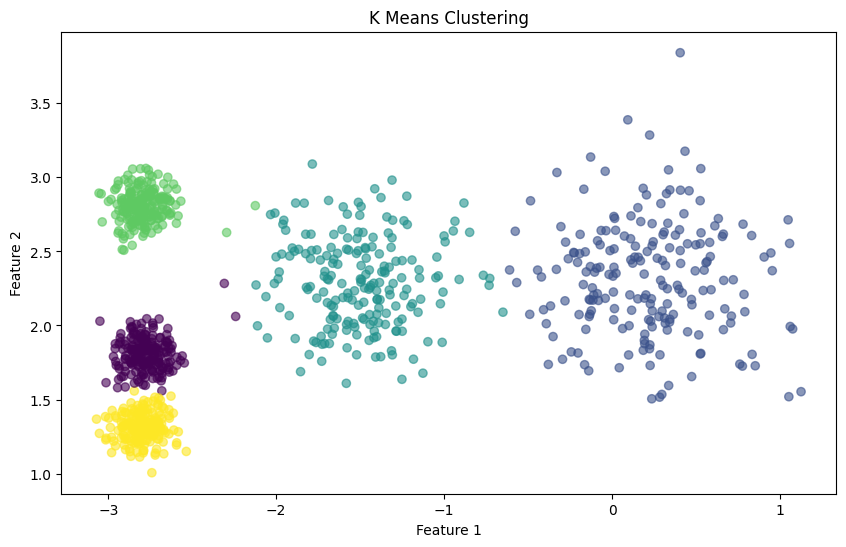

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1], c=y_pred, cmap="viridis", alpha=0.6)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("K Means Clustering")

plt.show()

### Voronoi Tessellation

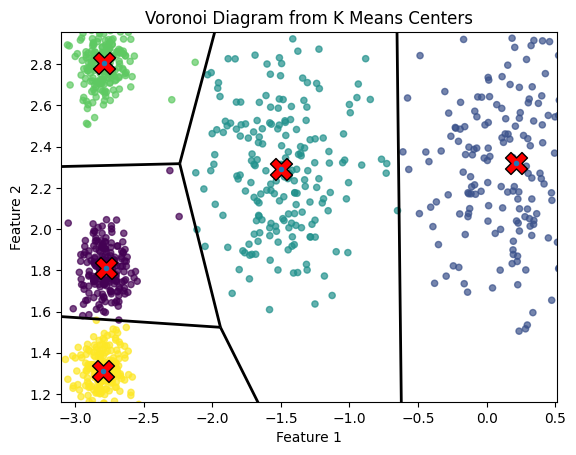

In [5]:
from scipy.spatial import Voronoi, voronoi_plot_2d

vor = Voronoi(kmeans.cluster_centers_)

fig = voronoi_plot_2d(vor, show_vertices=False, line_colors="black", line_width=2)
plt.scatter(X[:, 0], X[:, 1], c=y_pred, cmap="viridis", s=20, alpha=0.7)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], marker="X", s=250, c="red", edgecolor="black" )

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Voronoi Diagram from K Means Centers")
plt.show()

## Using Clustering for Image Segmentation

In [6]:
# import the python imaging library
import PIL
import numpy as np
filepath = '/Users/jhonchristianrozano/Documents/Programming/Python Programming/hands-on-machine-learning-book-codes/images/ladybug.png'
image = np.asarray(PIL.Image.open(filepath))

In [7]:
X = image.reshape(-1, 3)
print(X.shape)

(426400, 3)


In [8]:
kmeans = KMeans(n_clusters=8, random_state=42).fit(X)
segmented_img = kmeans.cluster_centers_[kmeans.labels_]
segmented_img = segmented_img.reshape(image.shape)

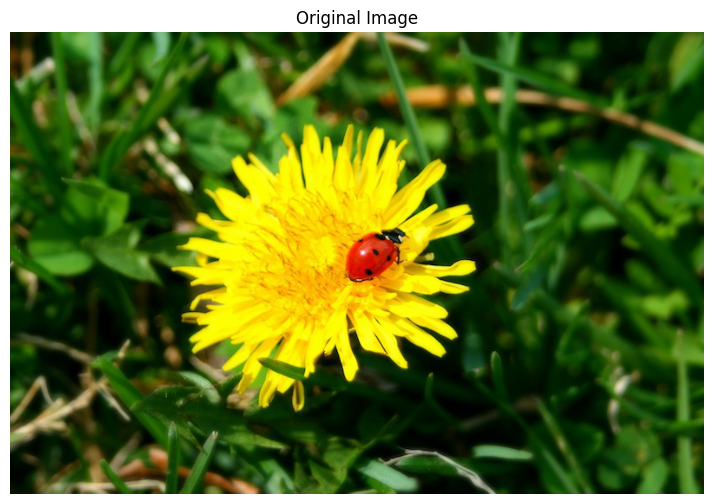

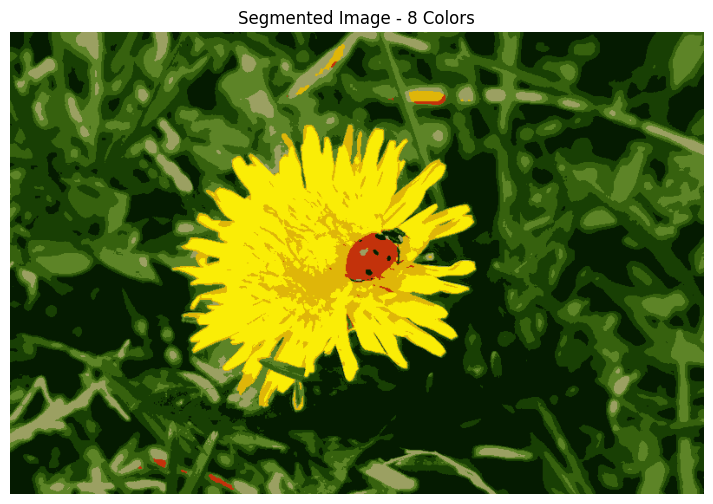

In [9]:
plt.figure(figsize=(10, 6))
plt.imshow(image)
plt.axis("off")
plt.title("Original Image")
plt.show()

plt.figure(figsize=(10, 6))
plt.imshow(segmented_img.astype(np.uint8))
plt.axis("off")
plt.title("Segmented Image - 8 Colors")
plt.show()

## Using Clustering for Semi-supervised Learning

In [10]:
from sklearn.datasets import load_digits
X_digits, y_digits = load_digits(return_X_y=True)
X_train, y_train = X_digits[:1400], y_digits[:1400]
X_test, y_test = X_digits[1400:], y_digits[1400:]

In [11]:
from sklearn.linear_model import LogisticRegression
n_labeled = 50
log_reg = LogisticRegression(max_iter=10_000)
log_reg.fit(X_train[:n_labeled], y_train[:n_labeled])

LogisticRegression(max_iter=10000)

In [12]:
log_reg.score(X_test, y_test)

0.7581863979848866

### Cluster the training set with 50 clusters to set these as representative images

In [13]:
k = 100
kmeans = KMeans(n_clusters=k, random_state=42)
X_digits_dist = kmeans.fit_transform(X_train)
representative_digit_idx = np.argmin(X_digits_dist, axis=0)
X_representative_digits = X_train[representative_digit_idx]

print(X_representative_digits.shape)

(100, 64)


### Training with the 50 representative clusters

(50, 64)


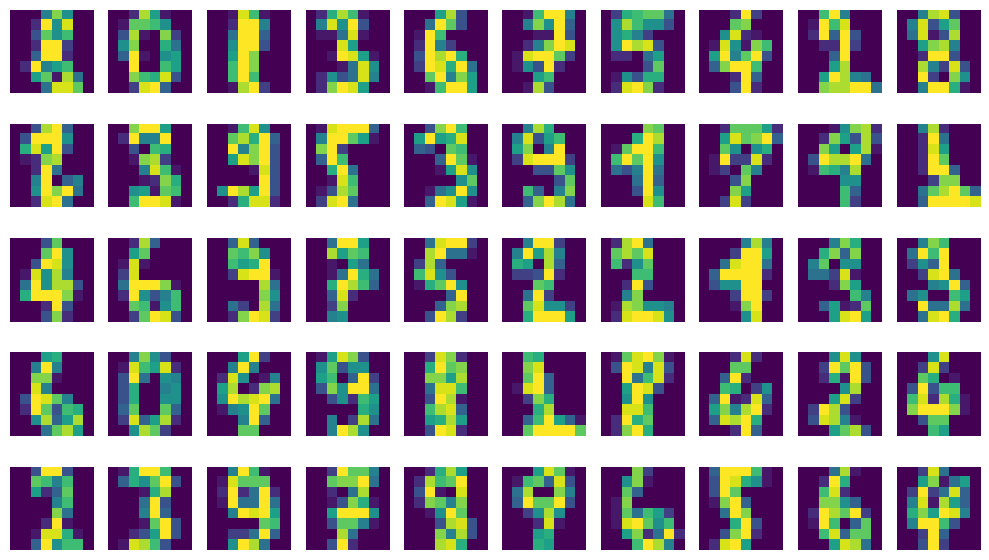

In [14]:
k = 50
kmeans = KMeans(n_clusters=k, random_state=42)
X_digits_dist = kmeans.fit_transform(X_train)
representative_digit_idx = np.argmin(X_digits_dist, axis=0)
X_representative_digits = X_train[representative_digit_idx]

print(X_representative_digits.shape)

import matplotlib.pyplot as plt

fig, axes = plt.subplots(5, 10, figsize=(10, 6))

for digit, ax in zip(X_representative_digits, axes.ravel()):
    ax.imshow(digit.reshape(8, 8))
    ax.axis("off")

plt.tight_layout()
plt.show()

In [15]:
y_representative_digits = np.array([
    8, 0, 1, 3, 6, 7, 5, 4, 2, 8,
    2, 3, 9, 5, 3, 9, 1, 7, 9, 1,
    4, 6, 9, 7, 5, 2, 2, 1, 3, 3,
    6, 0, 4, 9, 8, 1, 8, 4, 2, 4,
    2, 3, 9, 7, 8, 9, 6, 5, 6, 4
])

In [16]:
# using this labeled data, we perform logistic regression again
log_reg = LogisticRegression(max_iter=10_000)
log_reg.fit(X_representative_digits, y_representative_digits)
log_reg.score(X_test, y_test)

0.8312342569269522

In [17]:
y_train_propagated = np.empty(len(X_train), dtype=np.int64)
for cluster in range(k):
    y_train_propagated[kmeans.labels_ == cluster] = y_representative_digits[cluster]

In [18]:
log_reg = LogisticRegression(max_iter=10_000)
log_reg.fit(X_train, y_train_propagated)
log_reg.score(X_test, y_test)

0.8664987405541562

## DBSCAN Clustering

In [19]:
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons
X, y = make_moons(n_samples=1000, noise=0.05)
dbscan = DBSCAN(eps=0.20, min_samples=5)
dbscan.fit(X)

DBSCAN(eps=0.2)

In [20]:
dbscan.components_.shape

(1000, 2)

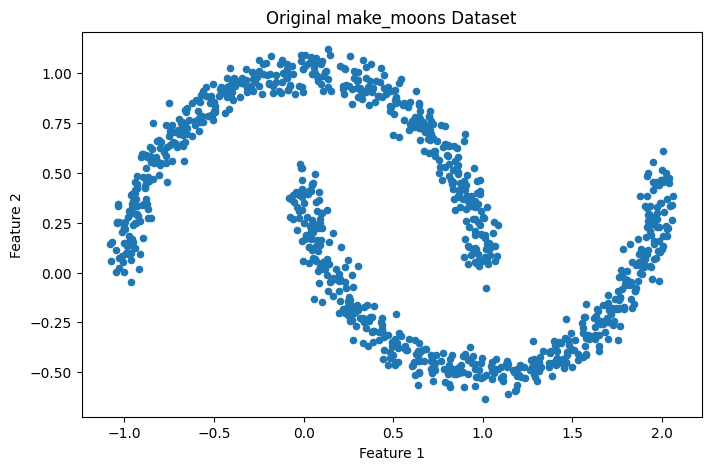

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(X[:, 0], X[:, 1], s=20)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Original make_moons Dataset")
plt.show()

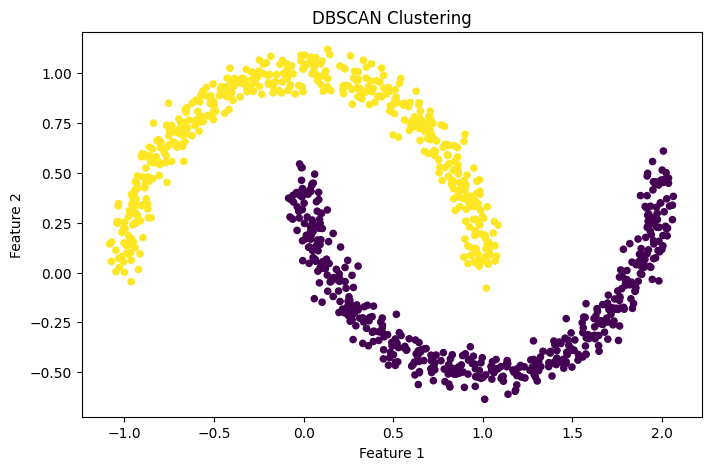

In [22]:
plt.figure(figsize=(8, 5))

plt.scatter(X[:, 0], X[:, 1], c=dbscan.labels_, cmap="viridis", s=20)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("DBSCAN Clustering")
plt.show()

In [23]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=50)
knn.fit(dbscan.components_, dbscan.labels_[dbscan.core_sample_indices_])

KNeighborsClassifier(n_neighbors=50)

In [24]:
X_new = np.array([[-0.5, 0], [0, 0.5], [1, -0.1], [2, 1]])
print(knn.predict(X_new))
print(knn.predict_proba(X_new))

[1 0 1 0]
[[0.16 0.84]
 [1.   0.  ]
 [0.2  0.8 ]
 [1.   0.  ]]


## Gaussian Model Mixture

In [25]:
X, y = make_moons(n_samples=1000, noise=0.05)

In [26]:
from sklearn.mixture import GaussianMixture
gm = GaussianMixture(n_components=3, n_init=10)
gm.fit(X)

GaussianMixture(n_components=3, n_init=10)

In [28]:
gm.weights_

array([0.20469792, 0.2012059 , 0.59409618])

In [29]:
gm.means_

array([[-0.74673617,  0.56315802],
       [ 1.75208356, -0.05439133],
       [ 0.50999591,  0.24397934]])

In [30]:
gm.covariances_

array([[[ 0.05571915,  0.06447966],
        [ 0.06447966,  0.08936668]],

       [[ 0.04947441,  0.0594852 ],
        [ 0.0594852 ,  0.08678236]],

       [[ 0.17065959, -0.10580676],
        [-0.10580676,  0.29236483]]])

In [32]:
densities = gm.score_samples(X)
density_threshold = np.percentile(densities, 2)
anomalies = X[densities < density_threshold]
anomalies


array([[-1.06133689e+00, -4.49387535e-02],
       [ 1.88682870e+00,  5.06549365e-01],
       [-9.21475046e-01,  6.22297482e-01],
       [-2.13489359e-01,  9.05462349e-01],
       [ 1.26692320e+00, -3.71734106e-01],
       [-2.18906754e-01,  8.76267431e-01],
       [ 1.31196983e+00, -3.55008049e-01],
       [-9.43881092e-01, -5.33451840e-02],
       [ 2.04151108e+00,  5.82485796e-01],
       [ 2.02527632e+00,  5.28088848e-01],
       [ 1.98714283e+00,  5.02340668e-01],
       [ 1.99950608e+00,  4.79975272e-01],
       [-7.32371164e-01,  8.54142639e-01],
       [-9.22305269e-01,  8.56754429e-04],
       [ 1.29777142e+00, -3.34688382e-01],
       [ 1.98039153e+00,  4.63729162e-01],
       [ 1.96731274e+00,  4.60158070e-01],
       [-9.55742611e-01,  6.32496440e-02],
       [-9.43581516e-01, -2.37948407e-02],
       [-9.81511921e-01, -1.37848298e-01]])

# Exercises
1. How would you define clustering? Can you name a few clustering algorithms?
   - Clustering is an algorithm that divides the data/instances into groups with similar attributes/characteristics. Clustering algorithms include KMeans, DBSCAN, Gaussian Mixture Model, and others.
2. What are some of the main applications of clustering algorithms?
   - Customer Segmentation, Image Segmentation, Anomaly Detection
3. Describe two techniques to select the right number of clusters when using k-means.
   - Inertia and Silhoutte Score
   - Inertia - the sum of the squared distances between every instance and its closest centroid.
   - Silhoutte score - measures how close the instance is to its cluster as well as to other clusters
4. What is label propagation? Why would you implement it, and how?
   - Label propagation is the process of spreading the label of a representative instance to the other instances in the same cluster. We can implement it if we don't have enough labeled dataset. To implement this, we first cluster the dataset into n-clusters and get the representatives from this, then, we propagate it to all the instances and then we train any machine learning models using the propagated y instances.
5. Can you name two clustering algorithms that can scale to large datasets? And two that look for regions of high density?
   - Scale well: KMeans and Mini-batch KMeans
   - Look for high density: GMM and Mean shift
6. Can you think of a use case where active learning would be useful? How would you implement it?
   - If we only have a few labeled data from the dataset. 
   - To implement, train with labeled dataset -> label the data with most uncertain (from the model) -> train -> repeat
7. What is the difference between anomaly detection and novelty detection?
   - Novelty detection assumes that the data is clean and there are no outliers, while the anomaly detection learns from the data itself to detect those that are in low-density regions.
8. What is a Gaussian mixture? What tasks can you use it for?
   - Gaussian mixture assumes that the instances/data come from a mixture of Gaussian distributions. Good for data that are in ellipsoid/elliptical shapes/shapes that vary. Good for clustering, density estimation, and anomaly detection.
9. Can you name two techniques to find the right number of clusters when using a Gaussian mixture model?
   - BIC and AIC


10. The classic Olivetti faces dataset contains 400 grayscale 64 × 64 pixel images of faces. Each image is flattened to a 1D vector of size 4,096. Forty different people were photographed (10 times each), and the usual task is to train a model that can predict which person is represented in each picture. Load the dataset using the `sklearn.datasets.fetch_olivetti_faces()` function, then split it into a training set, a validation set, and a test set (note that the dataset is already scaled between 0 and 1). Since the dataset is quite small, you will probably want to use stratified sampling to ensure that there are the same number of images per person in each set. Next, cluster the images using k-means, and ensure that you have a good number of clusters (using one of the techniques discussed in this chapter). Visualize the clusters: do you see similar faces in each cluster?

In [33]:
from sklearn.datasets import fetch_olivetti_faces
dataset = fetch_olivetti_faces()

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /Users/jhonchristianrozano/scikit_learn_data


In [34]:
help(fetch_olivetti_faces)

Help on function fetch_olivetti_faces in module sklearn.datasets._olivetti_faces:

fetch_olivetti_faces(*, data_home=None, shuffle=False, random_state=0, download_if_missing=True, return_X_y=False, n_retries=3, delay=1.0)
    Load the Olivetti faces data-set from AT&T (classification).

    Download it if necessary.

    =================   =====================
    Classes                                40
    Samples total                         400
    Dimensionality                       4096
    Features            real, between 0 and 1
    =================   =====================

    Read more in the :ref:`User Guide <olivetti_faces_dataset>`.

    Parameters
    ----------
    data_home : str or path-like, default=None
        Specify another download and cache folder for the datasets. By default
        all scikit-learn data is stored in '~/scikit_learn_data' subfolders.

    shuffle : bool, default=False
        If True the order of the dataset is shuffled to avoid having
 

In [53]:
from sklearn.model_selection import train_test_split
X, y = dataset.data, dataset.target

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.20, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, stratify=y_train, test_size=0.25, random_state=42)

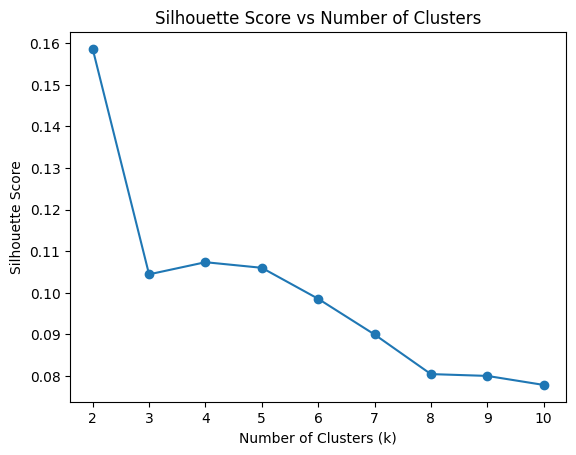

In [41]:
# determine the best k
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

silhouettes = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_train)

    score = silhouette_score(X_train, labels)
    silhouettes.append(score)

plt.plot(range(2, 11), silhouettes, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs Number of Clusters")
plt.show()


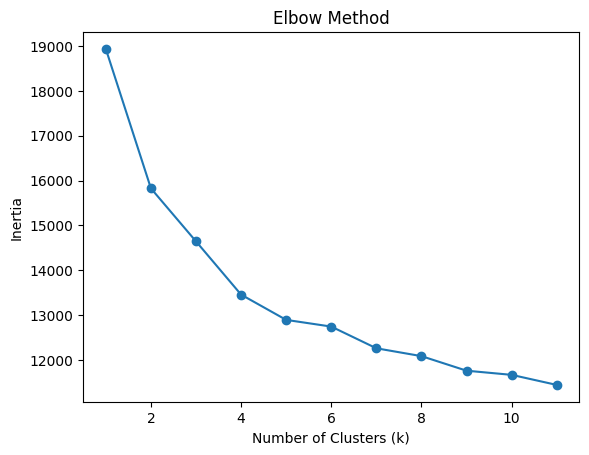

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

k_values = range(1, 12)
inertias = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_train)
    inertias.append(kmeans.inertia_)

plt.plot(k_values, inertias, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

### The best number of clusters based on the diagrams shown is k=4.

In [46]:
# we cluster using KMeans
kmeans_final = KMeans(n_clusters=4, random_state=42)
kmeans_final.fit(X_train)


KMeans(n_clusters=4, random_state=42)

In [49]:
cluster_images = X_train[kmeans.labels_ == 0]
cluster_images

array([[0.25619835, 0.40082645, 0.30165288, ..., 0.6528926 , 0.69008267,
        0.6983471 ],
       [0.553719  , 0.607438  , 0.6363636 , ..., 0.92975205, 0.88429755,
        0.822314  ],
       [0.7107438 , 0.7107438 , 0.70247936, ..., 0.553719  , 0.30991736,
        0.30991736],
       [0.6570248 , 0.6487603 , 0.6528926 , ..., 0.677686  , 0.59090906,
        0.6983471 ]], dtype=float32)

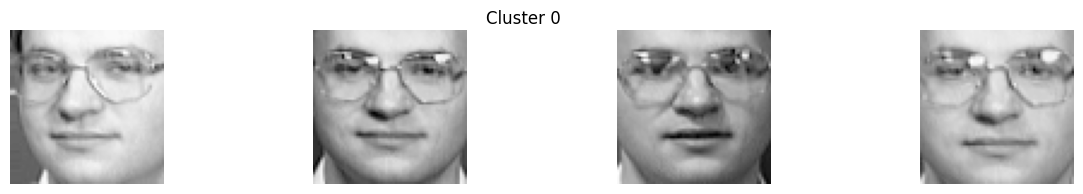

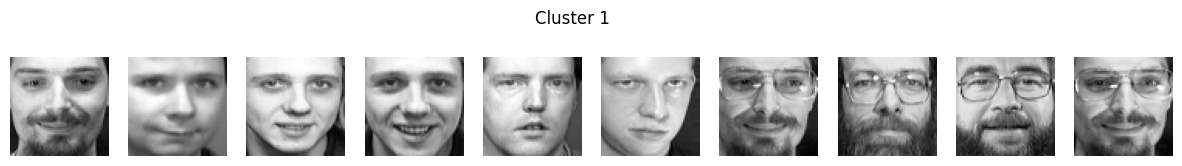

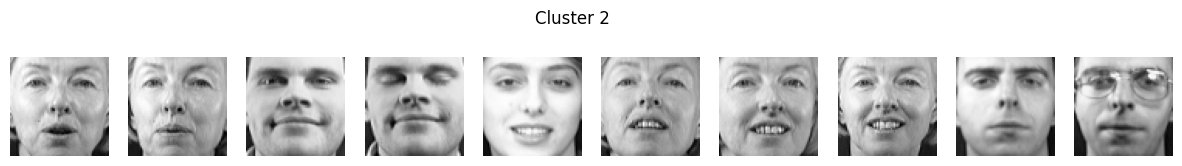

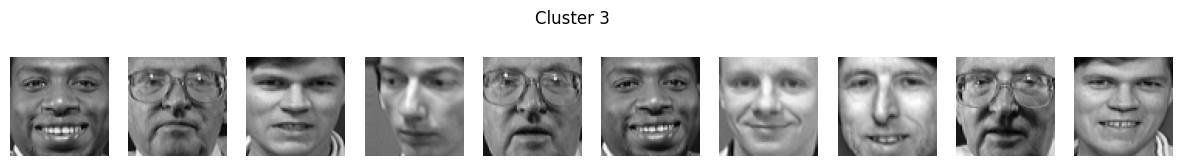

In [48]:
for cluster in range(4):
    cluster_images = X_train[kmeans.labels_ == cluster]
    fig, axes = plt.subplots(1, min(10, len(cluster_images)), figsize=(15, 2))

    for image, ax in zip(cluster_images[:10], axes):
        ax.imshow(image.reshape(64, 64), cmap="gray")
        ax.axis("off")

    plt.suptitle(f"Cluster {cluster}")
    plt.show()

11. Continuing with the Olivetti faces dataset, train a classifier to predict which person is represented in each picture, and evaluate it on the validation set. Next, use k-means as a dimensionality reduction tool, and train a classifier on the reduced set. Search for the number of clusters that allows the classifier to get the best performance: what performance can you reach? What if you append the features from the reduced set to the original features (again, searching for the best number of clusters)?

In [54]:
# training a classifier to predict and evaluating it on the validations set
from sklearn.ensemble import RandomForestClassifier
rnd_clf = RandomForestClassifier(random_state=42)
rnd_clf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [56]:
rnd_clf.score(X_val, y_val)

0.925

In [59]:
# use KMeans as a dimensionality reduction to train a new classifier
kmeans = KMeans(n_clusters=40, random_state=42)
kmeans.fit(X_train)

X_train_reduced = kmeans.transform(X_train)
X_val_reduced = kmeans.transform(X_val)

In [60]:
rnd_clf_reduced = RandomForestClassifier(random_state=42)
rnd_clf_reduced.fit(X_train_reduced, y_train)
rnd_clf_reduced.score(X_val_reduced, y_val)

0.75

In [64]:
# determining the best k for this

scores = []
for k in range(2, 101):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_train)

    X_train_reduced = kmeans.transform(X_train)
    X_val_reduced = kmeans.transform(X_val)

    rnd_clf_reduced = RandomForestClassifier(random_state=42)
    rnd_clf_reduced.fit(X_train_reduced, y_train)
    score = rnd_clf_reduced.score(X_val_reduced, y_val)
    scores.append(score)

In [66]:
max_index = scores.index(max(scores))
print(max_index)
print(max(scores))

65
0.875


### Appending the features from the reduced set to the original features

In [70]:
import numpy as np

scores_extended = []
for k in range(2, 101):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_train)

    X_train_reduced = kmeans.transform(X_train)
    X_val_reduced = kmeans.transform(X_val)

    X_train_extended = np.c_[X_train, X_train_reduced]
    X_val_extended = np.c_[X_val, X_val_reduced]

    rnd_clf_extended= RandomForestClassifier(random_state=42)
    rnd_clf_extended.fit(X_train_extended, y_train)

    score = rnd_clf_extended.score(X_val_extended, y_val)
    scores_extended.append(score)

In [71]:
max_index = scores_extended.index(max(scores_extended))
print(max_index)
print(max(scores_extended))

7
0.9625


12. Train a Gaussian mixture model on the Olivetti faces dataset. To speed up the algorithm, you should probably reduce the dataset’s dimensionality, for example using PCA while preserving 99% of the variance. Use the model to generate some new faces using the sample() method, and visualize them. If you used PCA, you will need to use its inverse_transform() method. Try modifying some images, for example by rotating, flipping, or darkening them, and see whether the model can detect the anomalies. Compare the output of the score_samples() method for normal images and for anomalies.

In [103]:
# reducing the dataset's dimensionality
from sklearn.decomposition import PCA
pca = PCA(n_components=0.99)
X_train_reduced = pca.fit_transform(X_train)

# clustering via GMM
from sklearn.mixture import GaussianMixture

bics = []
aics = []

for k in range(2, 41):
    gmm = GaussianMixture(n_components=k, n_init=10, random_state=42)
    gmm.fit(X_train_reduced)

    bic = gmm.bic(X_train_reduced)
    bics.append(bic)

    aic = gmm.aic(X_train_reduced)
    aics.append(aic)


In [104]:
print(X_train_reduced.shape)

(240, 176)


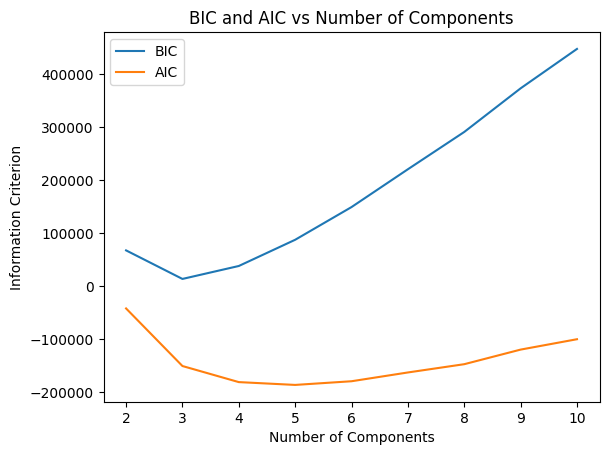

In [105]:
plt.plot(range(2, 11), bics[:9], label="BIC")
plt.plot(range(2, 11), aics[:9], label="AIC")
plt.xlabel("Number of Components")
plt.ylabel("Information Criterion")
plt.title("BIC and AIC vs Number of Components")
plt.legend()
plt.show()

In [106]:
min_bic = bics.index(min(bics))
min_aic = aics.index(min(aics))
print(min_bic, min_aic)

print(bics[:9], aics[:9])

1 3
[67523.04768460375, 13598.988081119896, 38045.53937211976, 87558.83099744312, 149333.20496863755, 220752.2632884956, 291197.4593195886, 373599.57354591426, 448031.7155175271] [-42134.48159528567, -150889.04615817592, -181272.99982658244, -186590.21316066547, -179646.34414887743, -163057.79078842583, -147443.09971673915, -119871.49044981983, -100269.85343761346]


In [107]:
best_n = 4
gmm = GaussianMixture(n_components=best_n, n_init=10, random_state=42)
gmm.fit(X_train_reduced)

GaussianMixture(n_components=4, n_init=10, random_state=42)

In [83]:
# generating a sample
X_new_reduced, y_new = gmm.sample(10)

In [86]:
X_new = pca.inverse_transform(X_new_reduced)
print(X_new.shape)

(10, 4096)


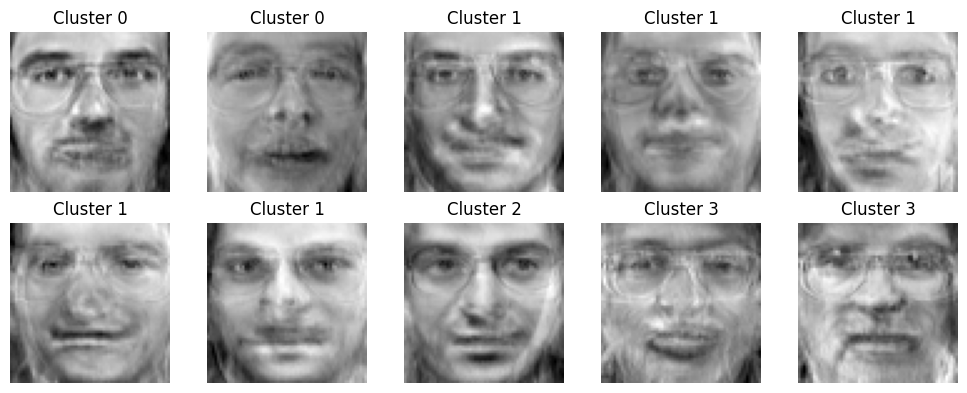

In [87]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for face, cluster, ax in zip(X_new, y_new, axes.ravel()):
    ax.imshow(face.reshape(64, 64), cmap="gray")
    ax.set_title(f"Cluster {cluster}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [95]:
n_rotated = 4
rotated = np.transpose(X_train[:n_rotated].reshape(-1, 64, 64), axes=[0, 2, 1])
rotated = rotated.reshape(-1, 64*64)
y_rotated = y_train[:n_rotated]

n_flipped = 3
flipped = X_train[:n_flipped].reshape(-1, 64, 64)[:, ::-1]
flipped = flipped.reshape(-1, 64*64)
y_flipped = y_train[:n_flipped]

n_darkened = 3
darkened = X_train[:n_darkened].copy()
darkened[:, 1:-1] *= 0.3
y_darkened = y_train[:n_darkened]

X_bad_faces = np.r_[rotated, flipped, darkened]
y_bad = np.concatenate([y_rotated, y_flipped, y_darkened])

In [98]:
X_bad_faces_pca = pca.transform(X_bad_faces)
gmm.score_samples(X_bad_faces_pca)

array([-10229458.6473035 , -15155724.21407929, -11594667.93972379,
       -20345013.84188081, -13136508.44016818, -15475304.66102823,
       -18880106.6662199 , -12469090.44876939, -15579360.54684473,
       -14224090.89630648])

In [108]:
gmm.score_samples(X_train_reduced[:10])

array([616.8345428 , 596.42615601, 641.51112256, 616.83435761,
       641.51111509, 616.83430087, 641.51142107, 616.83567224,
       641.51128733, 596.42637339])

13. Some dimensionality reduction techniques can also be used for anomaly detection. For example, take the Olivetti faces dataset and reduce it with PCA, preserving 99% of the variance. Then compute the reconstruction error for each image. Next, take some of the modified images you built in the previous exercise and look at their reconstruction error: notice how much larger it is. If you plot a reconstructed image, you will see why: it tries to reconstruct a normal face.

In [111]:
X_val_reduced = pca.transform(X_val)
X_val_reconstructed = pca.inverse_transform(X_val_reduced)

normal_errors = np.mean((X_val - X_val_reconstructed) ** 2, axis=1)
print(np.mean(normal_errors))

0.0022529706


In [113]:
X_train_pca = pca.transform(X_train)
X_train_reconstructed = pca.inverse_transform(X_train_pca)

normal_errors = np.mean((X_train - X_train_reconstructed) ** 2, axis=1)
print(np.mean(normal_errors))

0.00019093447


In [114]:
X_bad_faces_pca = pca.transform(X_bad_faces)
X_bad_faces_reconstructed = pca.inverse_transform(X_bad_faces_pca)

bad_errors = np.mean(
    (X_bad_faces - X_bad_faces_reconstructed) ** 2,
    axis=1
)

In [115]:
print("Average normal error:", normal_errors.mean())
print("Average anomaly error:", bad_errors.mean())

print("\nAnomaly reconstruction errors:")
print(bad_errors)

Average normal error: 0.00019093447
Average anomaly error: 0.006107058

Anomaly reconstruction errors:
[0.00644134 0.00978013 0.0090995  0.00877781 0.00658667 0.00882128
 0.00878816 0.00093868 0.00093949 0.00089753]


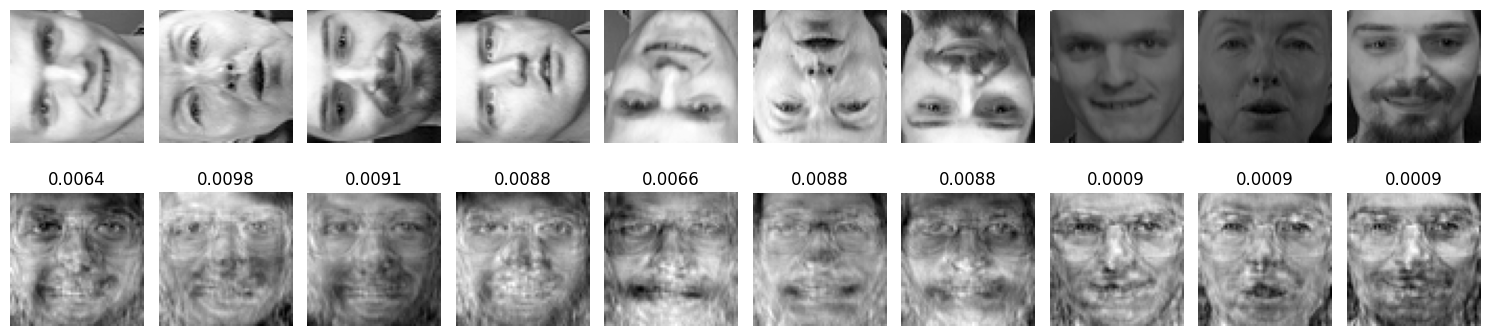

In [116]:
fig, axes = plt.subplots(2, 10, figsize=(15, 4))

for i in range(10):
    axes[0, i].imshow(X_bad_faces[i].reshape(64, 64), cmap="gray")
    axes[0, i].axis("off")

    axes[1, i].imshow(
        X_bad_faces_reconstructed[i].reshape(64, 64),
        cmap="gray"
    )
    axes[1, i].axis("off")
    axes[1, i].set_title(f"{bad_errors[i]:.4f}")

axes[0, 0].set_ylabel("Modified")
axes[1, 0].set_ylabel("Reconstructed")

plt.tight_layout()
plt.show()